In [1]:
# xarray to read NETCDF
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import dask as dd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
plt.rcParams['figure.dpi'] = 300

In [2]:
sst = xr.open_dataset('data/SST/sst.mnmean.nc')
sst_df = sst.to_dataframe().reset_index()

In [39]:
sst_df

,lat,lon,time,nbnds,time_bnds,sst,month,year
0,88.0,0.0,1854-01-01,0,9.969210e+36,-1.8,1,1854
1,88.0,0.0,1854-01-01,1,9.969210e+36,-1.8,1,1854
2,88.0,0.0,1854-02-01,0,9.969210e+36,-1.8,2,1854
3,88.0,0.0,1854-02-01,1,9.969210e+36,-1.8,2,1854
4,88.0,0.0,1854-03-01,0,9.969210e+36,-1.8,3,1854
...,...,...,...,...,...,...,...,...
65778115,-88.0,358.0,2024-11-01,1,9.969210e+36,NaN,11,2024
65778116,-88.0,358.0,2024-12-01,0,9.969210e+36,NaN,12,2024
65778117,-88.0,358.0,2024-12-01,1,9.969210e+36,NaN,12,2024
65778118,-88.0,358.0,2025-01-01,0,9.969210e+36,NaN,1,2025


In [3]:
chirps = xr.open_dataset('data/CHIRPS/chirps-v2.0.monthly.nc')

In [4]:
sst_df['month'] = sst_df['time'].dt.month
sst_df['year'] = sst_df['time'].dt.year

In [5]:
sst_df_jan = sst_df.query('month == 1')

In [6]:
chirps_eastern_east_africa = chirps.sel(latitude=slice(-3.5, 8), longitude=slice(38, 50)).to_dataframe().reset_index()
chirps_eastern_east_africa['month'] = chirps_eastern_east_africa['time'].dt.month
chirps_eastern_east_africa['year'] = chirps_eastern_east_africa['time'].dt.year

In [7]:
chirps_eastern_east_africa_jan = chirps_eastern_east_africa.query('month == 1').groupby(['month', 'year']).mean('precip').reset_index()

In [9]:
start_year = 1993
end_year = 2024

# Create a boolean mask
mask = (chirps_eastern_east_africa_jan['year'] >= start_year) & (chirps_eastern_east_africa_jan['year'] <= end_year)

# Apply the mask to filter the DataFrame
chirps_eastern_east_africa_jan = chirps_eastern_east_africa_jan[mask]

mask = (sst_df_jan['year'] >= start_year) & (sst_df_jan['year'] <= end_year)

sst_df_jan = sst_df_jan[mask]

In [10]:
chirps_eastern_east_africa_jan.quantile([0.33, 0.66])

,month,year,latitude,longitude,precip
0.33,1.0,2003.23,2.249998,43.999996,4.167859
0.66,1.0,2013.46,2.249998,43.999996,6.129906


In [17]:
jan_bn = chirps_eastern_east_africa_jan.query('precip <= 4.16786')['year'].to_list()

In [24]:
jan_n = chirps_eastern_east_africa_jan.query('4.16786 <= precip <= 6.12991')['year'].to_list()

In [25]:
jan_an = chirps_eastern_east_africa_jan.query('6.12991 <= precip')['year'].to_list()

In [42]:
sst_df_jan_bn = sst_df_jan[sst_df_jan['year'].isin(jan_bn)]
sst_df_jan_n = sst_df_jan[sst_df_jan['year'].isin(jan_n)]
sst_df_jan_an = sst_df_jan[sst_df_jan['year'].isin(jan_an)]

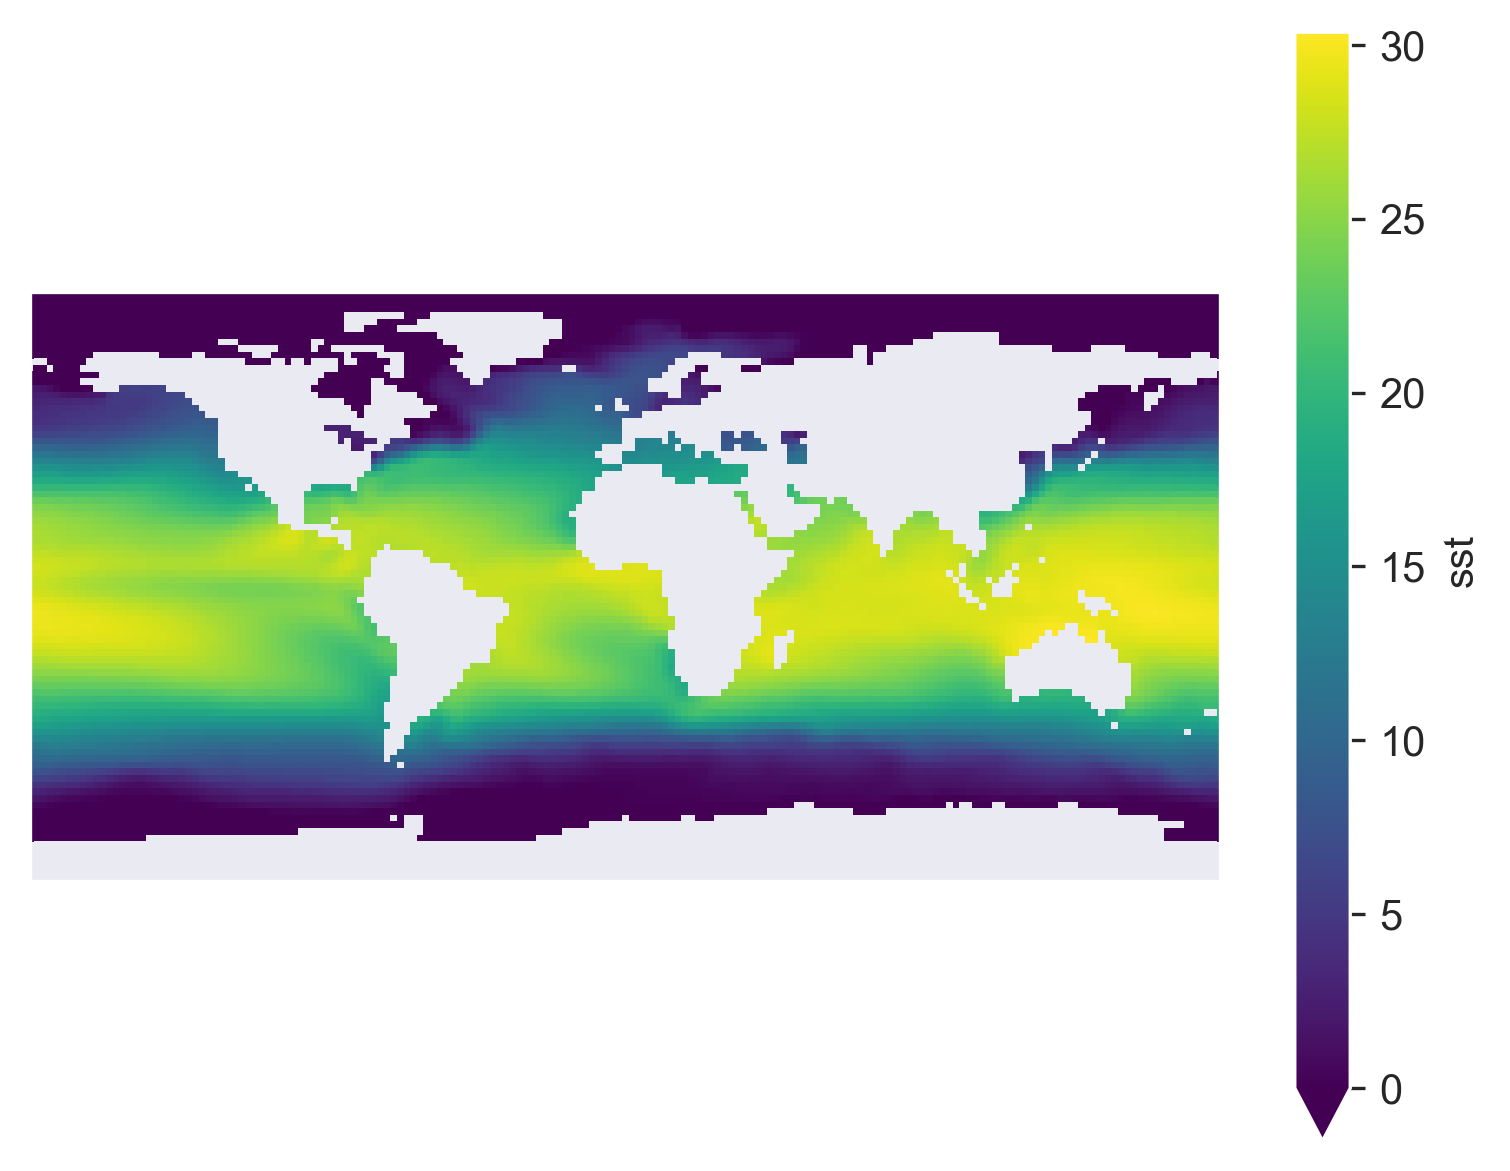

In [46]:
p = sst_df_jan_bn.drop(['year', 'month'], axis=1).groupby(['lat', 'lon']).mean('sst').reset_index().set_index(['lat', 'lon']).to_xarray()['sst'].plot(
    subplot_kws=dict(projection=ccrs.PlateCarree()),
    transform=ccrs.PlateCarree(), vmin=0
)
plt.savefig('figures/global_sst/sst_jan_bn.png')

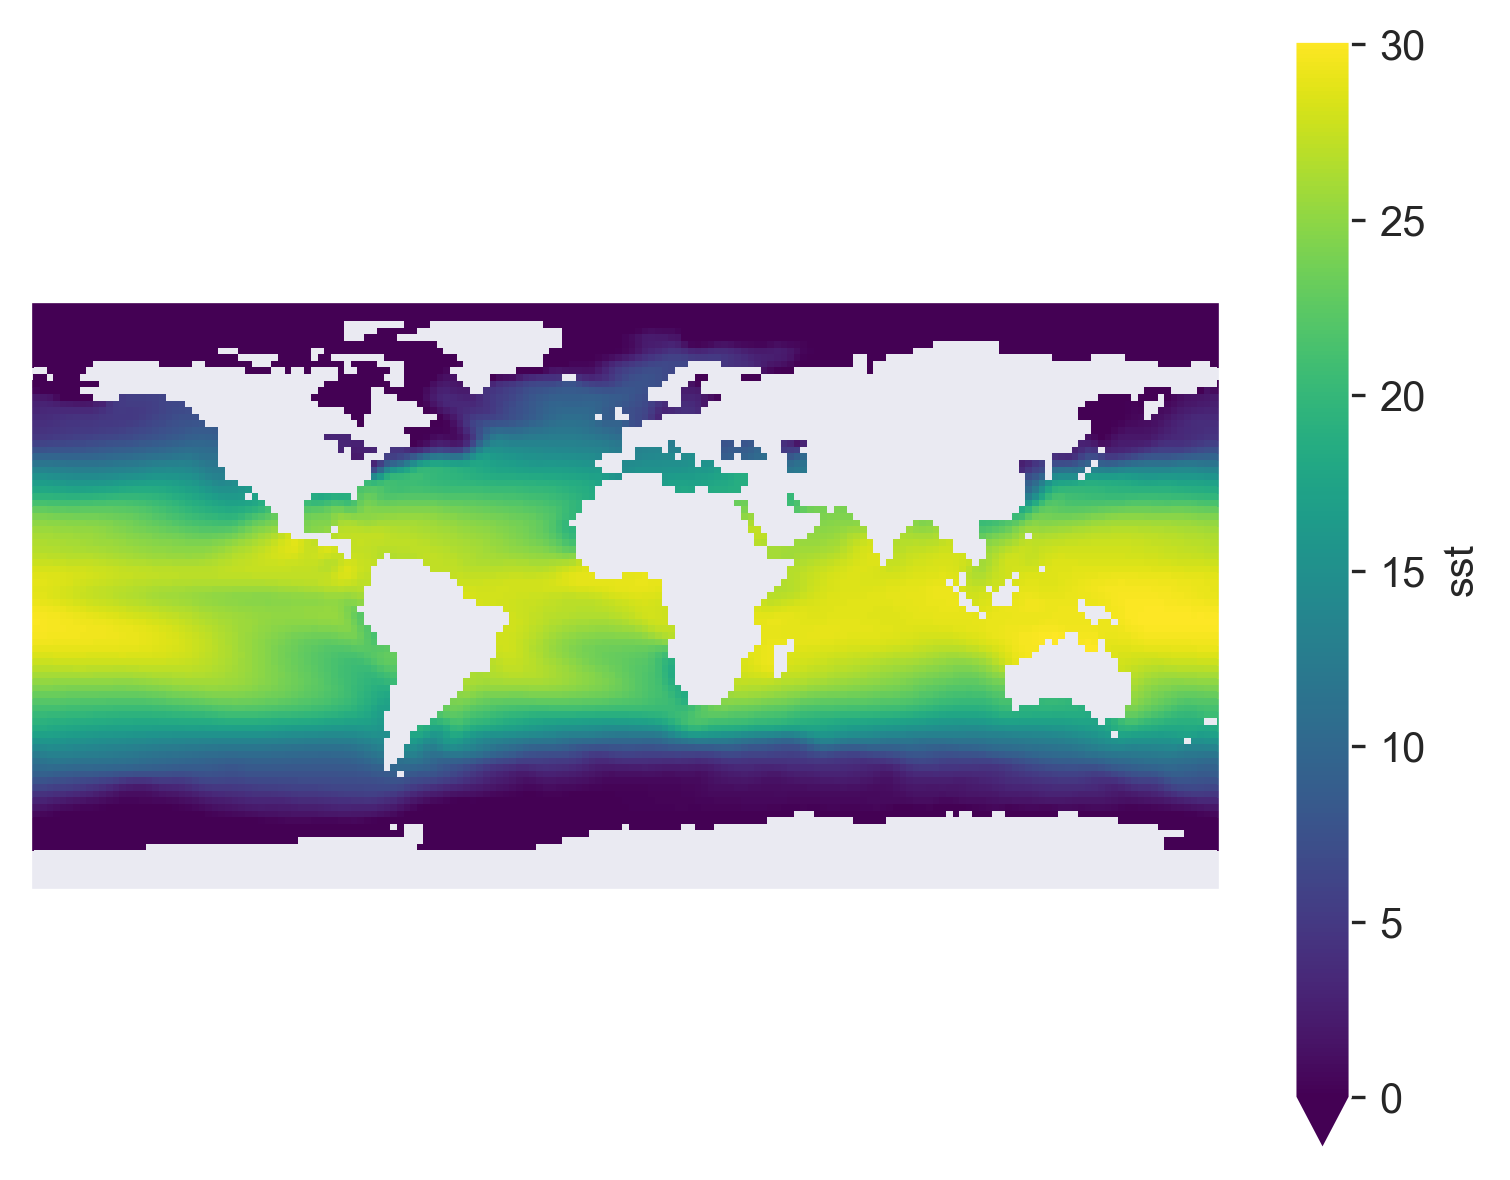

In [45]:
p = sst_df_jan_n.drop(['year', 'month'], axis=1).groupby(['lat', 'lon']).mean('sst').reset_index().set_index(['lat', 'lon']).to_xarray()['sst'].plot(
    subplot_kws=dict(projection=ccrs.PlateCarree()),
    transform=ccrs.PlateCarree(), vmin=0
)
plt.savefig('figures/global_sst/sst_jan_n.png')